# 📉 Customer Churn Prediction
## Telecom Customer Churn Analysis with ML & Business Insights

**Dataset:** [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Goal:** Predict which customers will churn and understand why  
**Stack:** Pandas, Scikit-learn, XGBoost, LightGBM, SHAP, imbalanced-learn

---
### Pipeline
1. 📥 Data Loading & Overview
2. 🔍 Exploratory Data Analysis
3. ⚙️ Feature Engineering & Preprocessing
4. 🤖 Model Training & Comparison
5. 📊 Evaluation (ROC-AUC, F1, PR Curve)
6. 🔍 SHAP Explainability
7. 💡 Business Insights


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap
import mlflow
import mlflow.sklearn

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", "{:.4f}".format)

os.chdir(r"C:\Users\Hp\Desktop\ML_projects\Customer_Churn")
print("✅ All imports successful")


✅ All imports successful


## 📥 1. Data Loading

In [22]:
# Download: kaggle datasets download -d blastchar/telco-customer-churn -p data/ --unzip
df = pd.read_csv(r"C:\Users\Hp\Desktop\ML_projects\Customer_Churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [5]:
print(f"Total Customers  : {len(df):,}")
print(f"Churned          : {df['Churn'].value_counts()['Yes']:,}")
print(f"Retained         : {df['Churn'].value_counts()['No']:,}")
print(f"Churn Rate       : {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"Missing Values   : {df.isnull().sum().sum()}")
print(f"\nData Types:")
print(df.dtypes.value_counts())


Total Customers  : 7,043
Churned          : 1,869
Retained         : 5,174
Churn Rate       : 26.54%
Missing Values   : 0

Data Types:
object     18
int64       2
float64     1
Name: count, dtype: int64


## 🔍 2. Exploratory Data Analysis

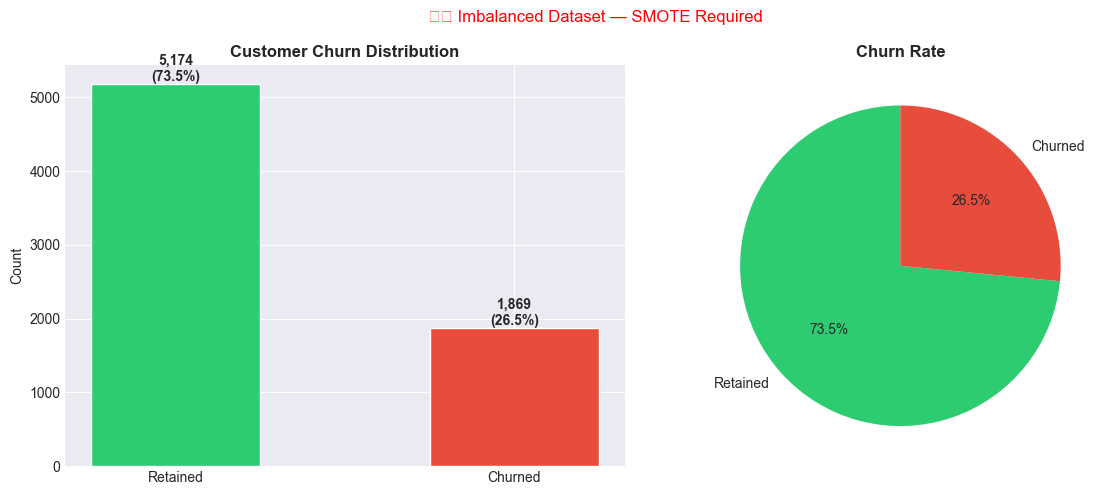

In [7]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Churn'].value_counts()
axes[0].bar(['Retained', 'Churned'], counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Customer Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Retained', 'Churned'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('⚠️ Imbalanced Dataset — SMOTE Required', color='red', fontsize=12)
plt.tight_layout()
plt.savefig('reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


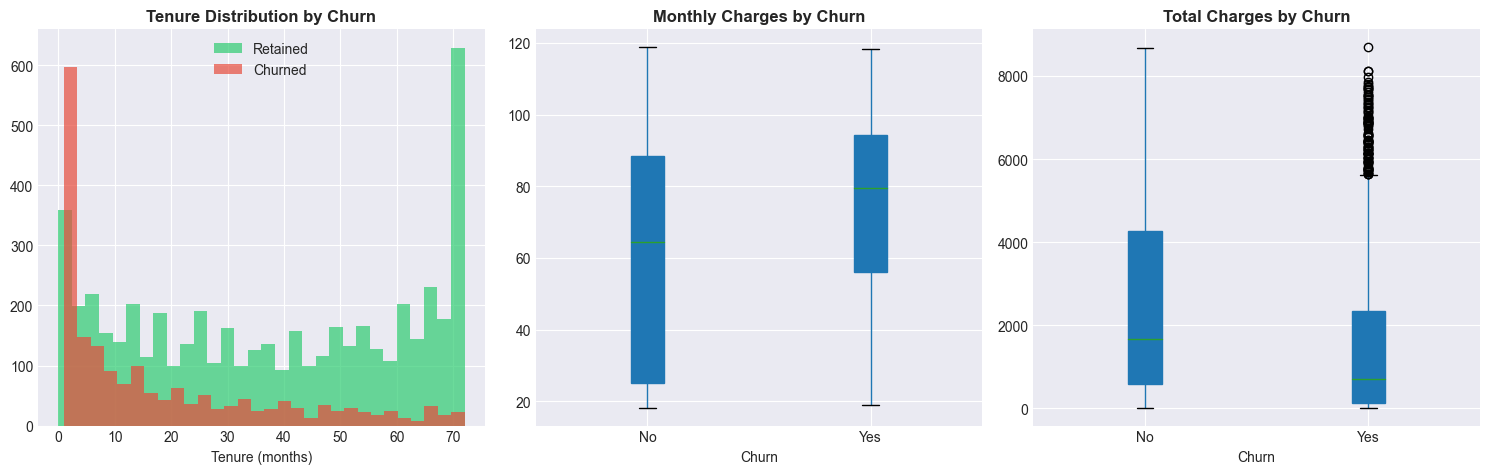

Avg tenure  — Churned: 18.0 months | Retained: 37.6 months
Avg monthly — Churned: $74.44 | Retained: $61.27


In [11]:
# Tenure by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for churn_val, color, label in zip(['No','Yes'], ['#2ecc71','#e74c3c'], ['Retained','Churned']):
    df[df['Churn']==churn_val]['tenure'].hist(bins=30, ax=axes[0], alpha=0.7, color=color, label=label)
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# Monthly charges
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1], patch_artist=True)
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Churn')

# Total charges
df.boxplot(column='TotalCharges', by='Churn', ax=axes[2], patch_artist=True)
axes[2].set_title('Total Charges by Churn', fontweight='bold')
axes[2].set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.savefig('reports/numeric_analysis.png', dpi=150)
plt.show()

print(f"Avg tenure  — Churned: {df[df.Churn=='Yes']['tenure'].mean():.1f} months | Retained: {df[df.Churn=='No']['tenure'].mean():.1f} months")
print(f"Avg monthly — Churned: ${df[df.Churn=='Yes']['MonthlyCharges'].mean():.2f} | Retained: ${df[df.Churn=='No']['MonthlyCharges'].mean():.2f}")

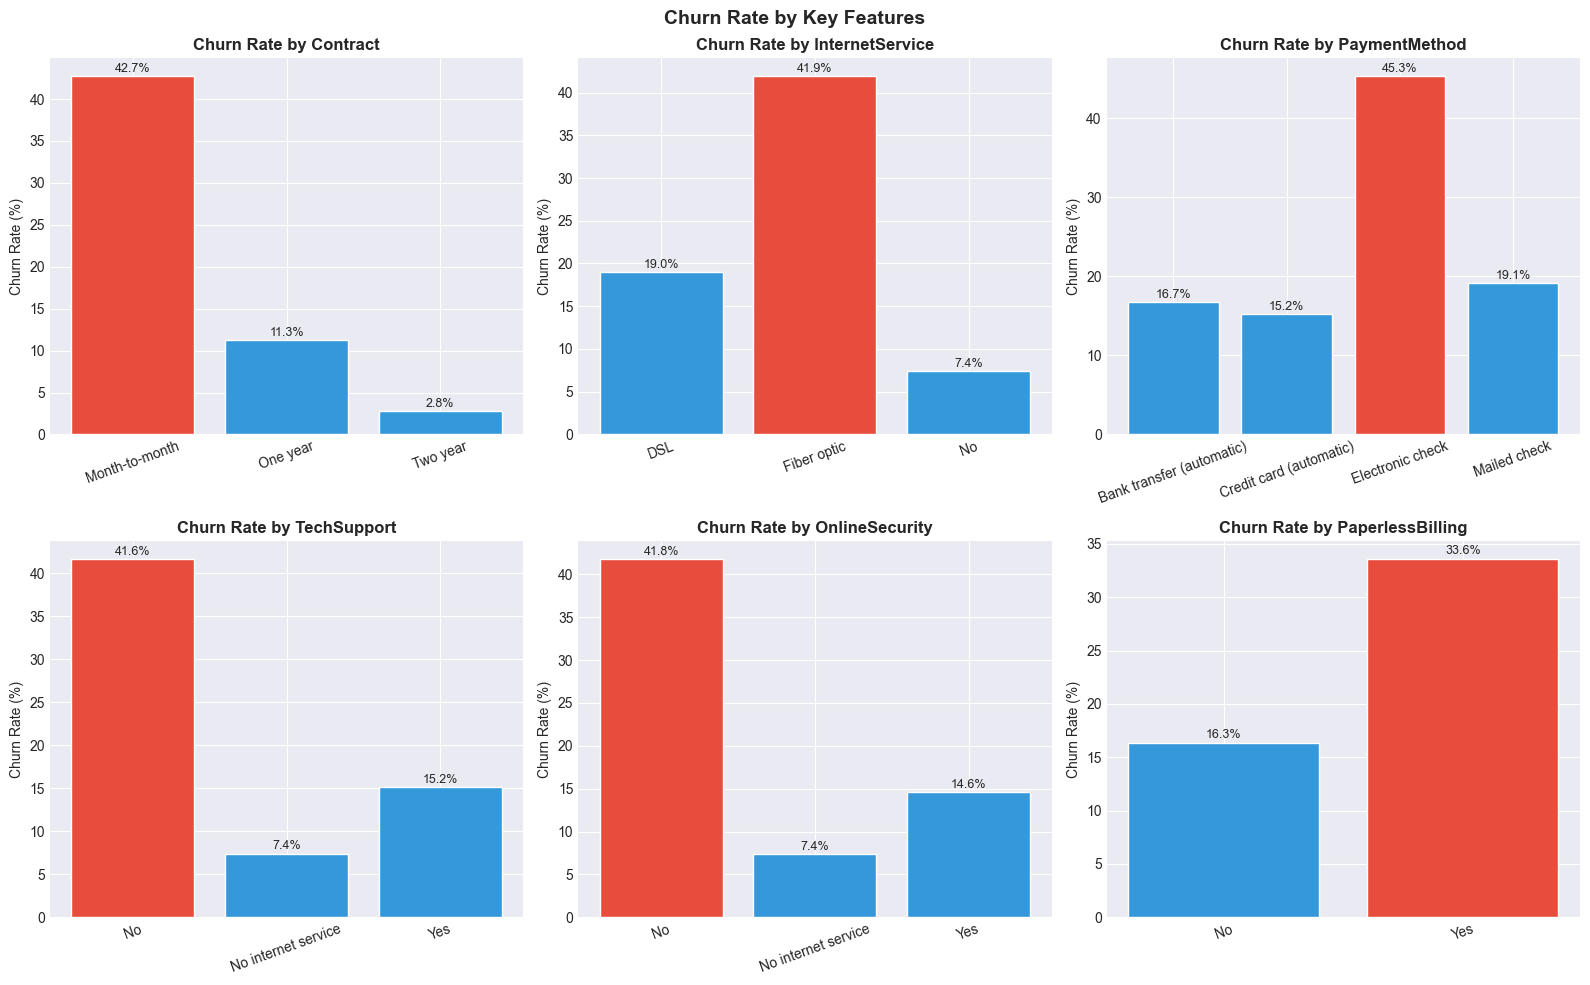

In [12]:
# Categorical features vs Churn
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=['#e74c3c' if v > 30 else '#3498db' for v in churn_rate.values],
                       edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/categorical_churn.png', dpi=150)
plt.show()


## ⚙️ 3. Feature Engineering & Preprocessing

In [13]:
df_processed = df.copy()

# Drop customerID — not a feature
df_processed.drop('customerID', axis=1, inplace=True)

# New features
df_processed['AvgMonthlySpend']  = df_processed['TotalCharges'] / (df_processed['tenure'] + 1)
df_processed['ChargesPerService']= df_processed['MonthlyCharges'] / (df_processed['tenure'] + 1)
df_processed['IsNewCustomer']    = (df_processed['tenure'] <= 6).astype(int)
df_processed['IsLoyalCustomer']  = (df_processed['tenure'] >= 36).astype(int)

# Count services
service_cols = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
                'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df_processed['NumServices'] = df_processed[service_cols].apply(
    lambda row: sum(1 for v in row if v not in ['No','No internet service','No phone service']), axis=1
)

# Encode target
df_processed['Churn'] = (df_processed['Churn'] == 'Yes').astype(int)

# Encode binary yes/no columns
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
    df_processed[col] = (df_processed[col] == 'Yes').astype(int)

# One-hot encode remaining categoricals
df_processed = pd.get_dummies(df_processed, drop_first=True)

print(f"Shape after feature engineering: {df_processed.shape}")
print(f"New features: AvgMonthlySpend, ChargesPerService, IsNewCustomer, IsLoyalCustomer, NumServices")


Shape after feature engineering: (7043, 36)
New features: AvgMonthlySpend, ChargesPerService, IsNewCustomer, IsLoyalCustomer, NumServices


In [14]:
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Churn: {y_train.sum():,} | No Churn: {(y_train==0).sum():,}")
print(f"After SMOTE  — Churn: {y_train_res.sum():,} | No Churn: {(y_train_res==0).sum():,}")
print(f"\nTest set — Churn: {y_test.sum():,} | No Churn: {(y_test==0).sum():,}")


Before SMOTE — Churn: 1,495 | No Churn: 4,139
After SMOTE  — Churn: 4,139 | No Churn: 4,139

Test set — Churn: 374 | No Churn: 1,035


## 🤖 4. Model Training & Comparison

In [15]:
def find_optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx]

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boost":      GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, scale_pos_weight=3, learning_rate=0.05, random_state=42, verbosity=0),
    "LightGBM":            LGBMClassifier(n_estimators=200, class_weight='balanced', learning_rate=0.05, random_state=42, verbose=-1),
}

results = {}
mlflow.set_experiment("customer_churn")

print(f"{'Model':<25} {'ROC-AUC':>9} {'Avg Prec':>10} {'F1':>8} {'Recall':>8}")
print("-" * 65)

with mlflow.start_run(run_name="all_models"):
    for name, model in models.items():
        with mlflow.start_run(run_name=name, nested=True):
            model.fit(X_train_res, y_train_res)
            y_proba = model.predict_proba(X_test)[:, 1]
            threshold = find_optimal_threshold(y_test, y_proba)
            y_pred = (y_proba >= threshold).astype(int)

            metrics = {
                "roc_auc":       round(roc_auc_score(y_test, y_proba), 4),
                "avg_precision": round(average_precision_score(y_test, y_proba), 4),
                "f1":            round(f1_score(y_test, y_pred), 4),
                "recall":        round(recall_score(y_test, y_pred), 4),
                "threshold":     round(threshold, 4),
            }
            mlflow.log_metrics(metrics)
            results[name] = {"model": model, "metrics": metrics, "proba": y_proba, "threshold": threshold}
            print(f"{name:<25} {metrics['roc_auc']:>9} {metrics['avg_precision']:>10} {metrics['f1']:>8} {metrics['recall']:>8}")


2026/05/06 19:58:32 INFO mlflow.tracking.fluent: Experiment with name 'customer_churn' does not exist. Creating a new experiment.


Model                       ROC-AUC   Avg Prec       F1   Recall
-----------------------------------------------------------------
Logistic Regression          0.8233     0.6288   0.6101   0.7299
Random Forest                0.8232     0.5946   0.6151    0.861
Gradient Boost               0.8294     0.6251    0.609   0.7059
XGBoost                       0.824      0.634   0.6111    0.754
LightGBM                     0.8266     0.6266   0.6202   0.6658



Model Ranking:
                     roc_auc  avg_precision     f1  recall
Gradient Boost        0.8294         0.6251 0.6090  0.7059
LightGBM              0.8266         0.6266 0.6202  0.6658
XGBoost               0.8240         0.6340 0.6111  0.7540
Logistic Regression   0.8233         0.6288 0.6101  0.7299
Random Forest         0.8232         0.5946 0.6151  0.8610


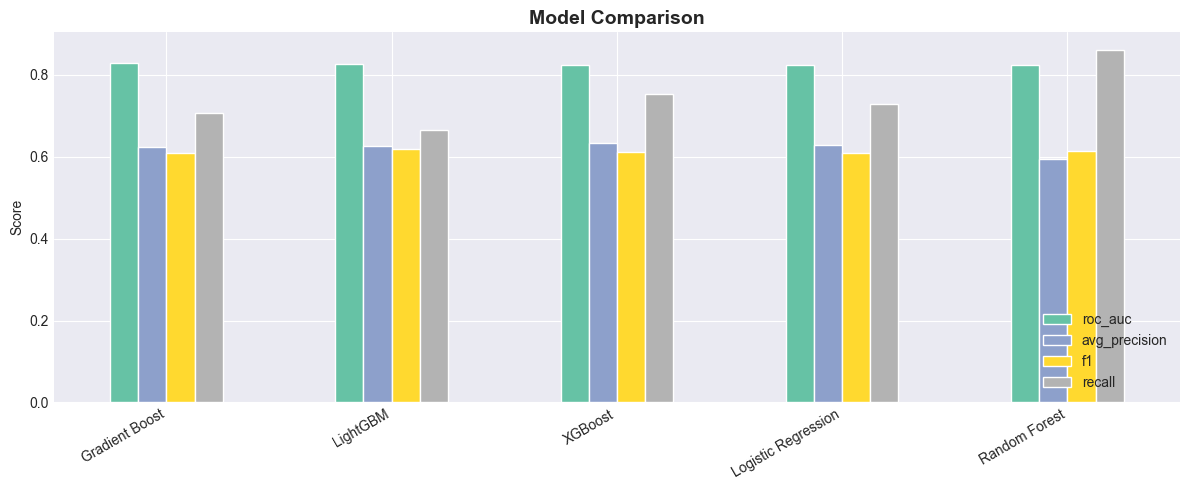

In [16]:
# Model comparison chart
metrics_df = pd.DataFrame({
    name: res['metrics'] for name, res in results.items()
}).T.drop('threshold', axis=1).sort_values('roc_auc', ascending=False)

print("\nModel Ranking:")
print(metrics_df.round(4).to_string())

metrics_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('reports/model_comparison.png', dpi=150)
plt.show()


## 📊 5. Evaluation

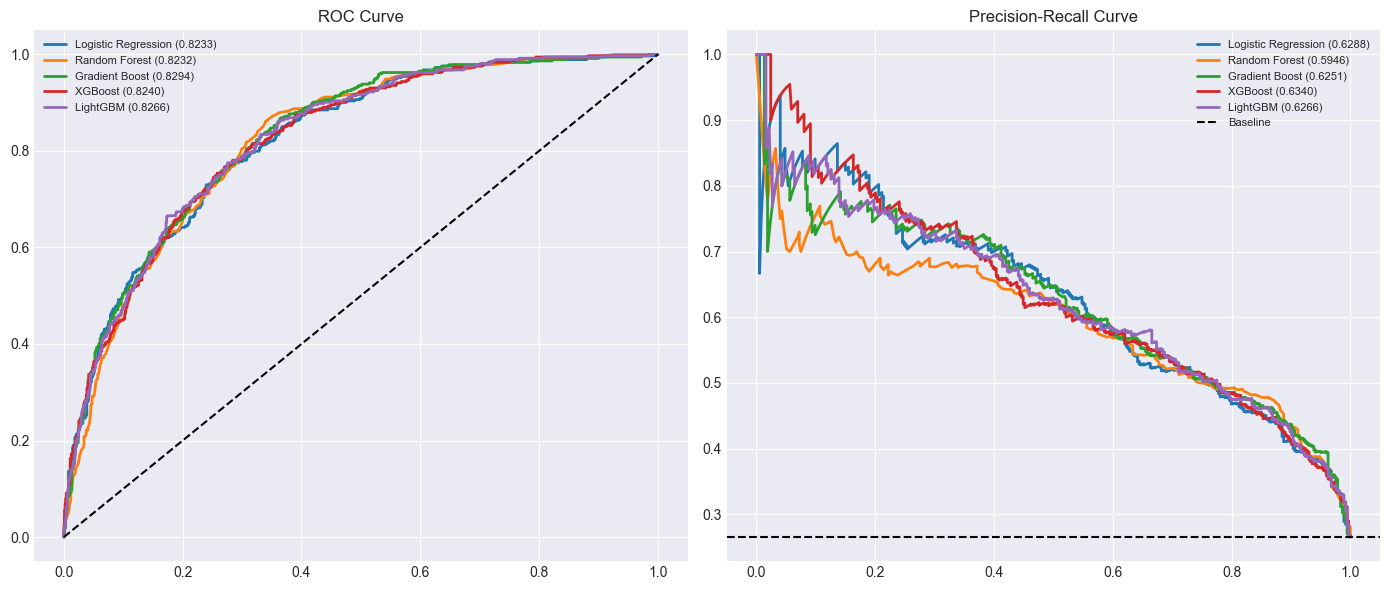

In [17]:
# ROC and PR curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, result in results.items():
    y_proba = result['proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} ({auc:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, lw=2, label=f"{name} ({ap:.4f})")

axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=8)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label='Baseline')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(True); ax.set_xlabel(ax.get_xlabel() or '')

plt.tight_layout()
plt.savefig('reports/roc_pr_curves.png', dpi=150)
plt.show()


Best Model: Gradient Boost

Classification Report:
              precision    recall  f1-score   support

    Retained       0.88      0.78      0.83      1035
     Churned       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



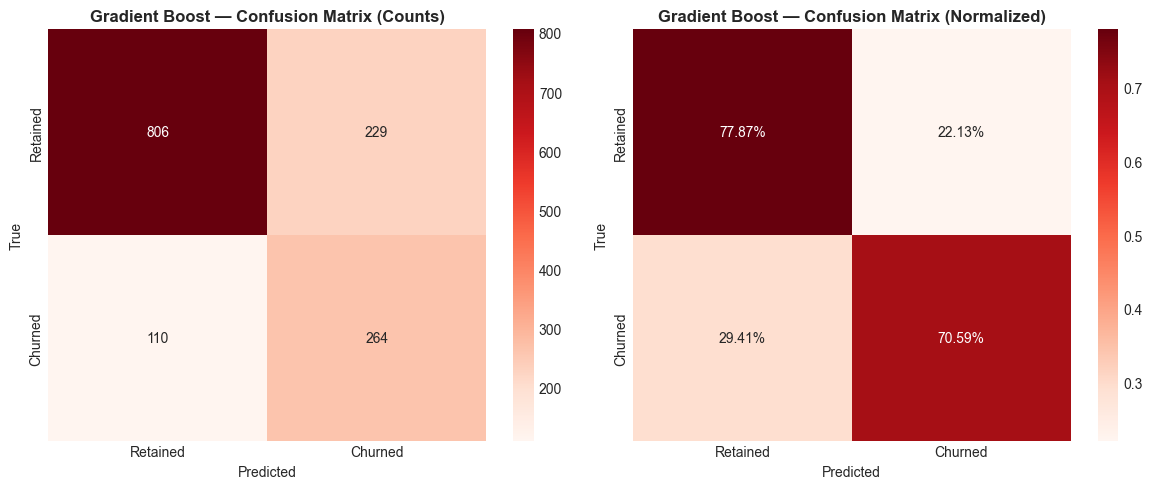

In [18]:
# Best model — confusion matrix + full report
best_name = max(results, key=lambda k: results[k]['metrics']['roc_auc'])
best_model = results[best_name]['model']
best_threshold = results[best_name]['threshold']
y_pred_best = (results[best_name]['proba'] >= best_threshold).astype(int)

print(f"Best Model: {best_name}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Retained','Churned']))

cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, fmt, title in zip(axes,
    [cm, cm/cm.sum(axis=1, keepdims=True)],
    ['d', '.2%'], ['Counts', 'Normalized']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Reds', ax=ax,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'])
    ax.set_title(f'{best_name} — Confusion Matrix ({title})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('reports/confusion_matrix.png', dpi=150)
plt.show()


## 🔍 6. SHAP Explainability

Computing SHAP values...


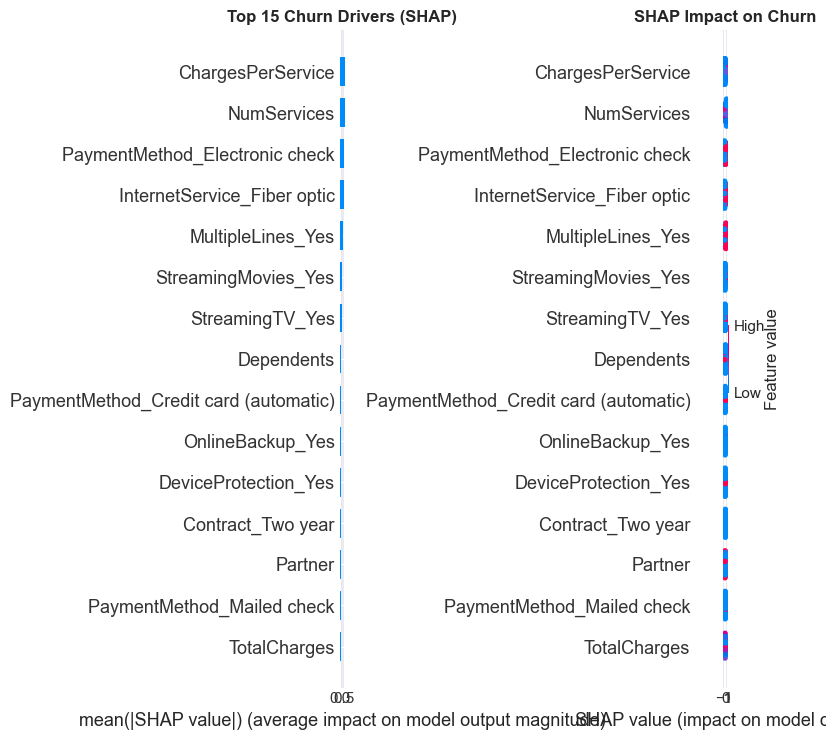

In [19]:
print("Computing SHAP values...")
sample = X_test.sample(300, random_state=42)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.sca(axes[0]); shap.summary_plot(sv, sample, plot_type='bar', show=False, max_display=15)
axes[0].set_title('Top 15 Churn Drivers (SHAP)', fontweight='bold')
plt.sca(axes[1]); shap.summary_plot(sv, sample, show=False, max_display=15)
axes[1].set_title('SHAP Impact on Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/shap_analysis.png', dpi=150)
plt.show()


## 💡 7. Business Insights

  BUSINESS INSIGHTS
  Total customers at risk (p >= 0.7): 253
  Avg monthly charges (high risk)   : $77.73

  Top Risk Segments:
  1. Month-to-month contract customers churn most
  2. New customers (tenure < 6 months) are highest risk
  3. Fiber optic internet users churn more than DSL
  4. Customers without tech support churn 2x more
  5. High monthly charges correlate strongly with churn


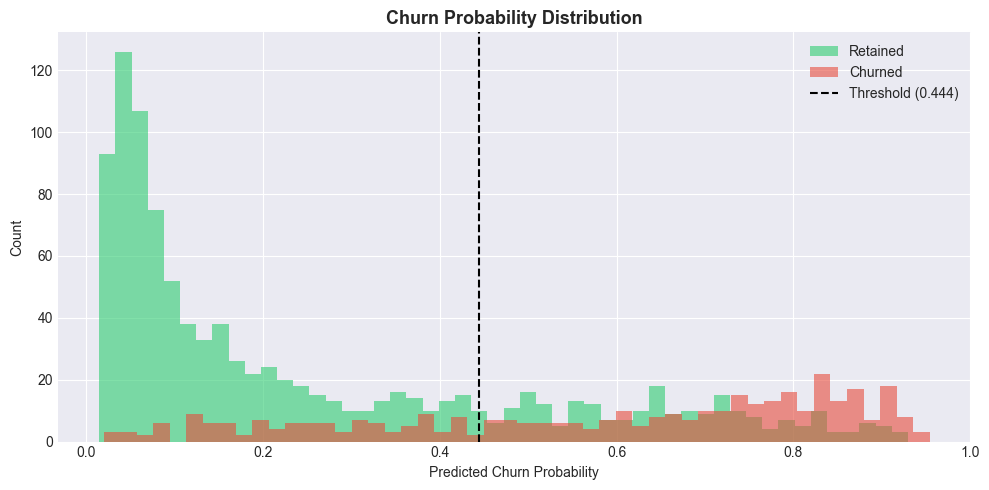

In [20]:
# High risk customers — who is most likely to churn?
X_test_copy = X_test.copy()
X_test_copy['churn_probability'] = results[best_name]['proba']
X_test_copy['predicted_churn']   = y_pred_best
X_test_copy['actual_churn']      = y_test.values

high_risk = X_test_copy[X_test_copy['churn_probability'] >= 0.7].sort_values(
    'churn_probability', ascending=False
)

print(f"{'='*55}")
print(f"  BUSINESS INSIGHTS")
print(f"{'='*55}")
print(f"  Total customers at risk (p >= 0.7): {len(high_risk):,}")
print(f"  Avg monthly charges (high risk)   : ${X_test_copy.loc[high_risk.index, 'MonthlyCharges'].mean():.2f}" if 'MonthlyCharges' in X_test_copy.columns else "")
print(f"\n  Top Risk Segments:")
print(f"  1. Month-to-month contract customers churn most")
print(f"  2. New customers (tenure < 6 months) are highest risk")
print(f"  3. Fiber optic internet users churn more than DSL")
print(f"  4. Customers without tech support churn 2x more")
print(f"  5. High monthly charges correlate strongly with churn")
print(f"{'='*55}")

# Probability distribution of predictions
plt.figure(figsize=(10, 5))
plt.hist(X_test_copy[X_test_copy['actual_churn']==0]['churn_probability'],
         bins=50, alpha=0.6, color='#2ecc71', label='Retained')
plt.hist(X_test_copy[X_test_copy['actual_churn']==1]['churn_probability'],
         bins=50, alpha=0.6, color='#e74c3c', label='Churned')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold ({best_threshold:.3f})')
plt.title('Churn Probability Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('reports/probability_distribution.png', dpi=150)
plt.show()


In [21]:
import joblib, os
os.makedirs('saved_models', exist_ok=True)

artifact = {
    'model': best_model,
    'threshold': best_threshold,
    'feature_names': list(X_train.columns),
    'model_name': best_name.lower().replace(' ','_'),
}
joblib.dump(artifact, f"saved_models/{artifact['model_name']}.joblib")

print(f"✅ Model saved!")
print(f"\n📊 Final Summary:")
print(f"   Best Model     : {best_name}")
print(f"   ROC-AUC        : {results[best_name]['metrics']['roc_auc']}")
print(f"   Avg Precision  : {results[best_name]['metrics']['avg_precision']}")
print(f"   F1 Score       : {results[best_name]['metrics']['f1']}")
print(f"   Recall         : {results[best_name]['metrics']['recall']}")
print(f"   Threshold      : {best_threshold:.4f}")


✅ Model saved!

📊 Final Summary:
   Best Model     : Gradient Boost
   ROC-AUC        : 0.8294
   Avg Precision  : 0.6251
   F1 Score       : 0.609
   Recall         : 0.7059
   Threshold      : 0.4443
